In [2]:
import os 
import pandas as pd
from tqdm import tqdm
import shutil
import json
import os
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from matplotlib import pyplot as plt

# for preprocessing and kilosort
from spikeinterface import core as si
from spikeinterface import extractors as se
from spikeinterface import preprocessing as sp
from spikeinterface import widgets as sw
from spikeinterface import sorters as ss
from spikeinterface import curation as sc
from spikeinterface import postprocessing as pp
from spikeinterface import qualitymetrics as qm
from spikeinterface import exporters as sx
from spikeinterface import qualitymetrics as sq

# get probe data for cambridge neurotech probe
from probeinterface.plotting import plot_probe
from pathlib import Path

In [3]:
raw_file_for_serial_number_extraction = "/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/2025-06-05_11-09-04"

In [4]:
SUBJECT_IDS = ["ah10", "ly07", "ly05", "ah08", "ly06"]
SUBJECT2STREAM_ID = {
    "ah10": "0",
    "ly07": "1",
    "ly05": "2",
    "ah08": "3",
    "ly06": "4",
}  # for reading multi-animal ephys recording folders

STREAM_ID2SUBJECT = {
    "0": "ah10",
    "1": "ly07",
    "2": "ly05",
    "3": "ah08",
    "4": "ly06"}

In [5]:
stream_names, stream_ids = se.get_neo_streams('openephysbinary', raw_file_for_serial_number_extraction)
print("Stream Names: ", stream_names)
print("Stream IDs: ", stream_ids)

Stream Names:  ['Record Node 104#Neuropix-PXI-100.ProbeA', 'Record Node 104#Neuropix-PXI-100.ProbeB', 'Record Node 104#Neuropix-PXI-100.ProbeC', 'Record Node 104#Neuropix-PXI-100.ProbeD', 'Record Node 104#Neuropix-PXI-100.ProbeE']
Stream IDs:  ['0', '1', '2', '3', '4']


In [6]:
subject_serial_numbers = {}



stream_names, stream_ids = se.get_neo_streams('openephysbinary', raw_file_for_serial_number_extraction)
print("Stream Names: ", stream_names)
print("Stream IDs: ", stream_ids)


for stream_name, stream_id in zip(stream_names, stream_ids):
    print(f"Stream Name: {stream_name}, Stream ID: {stream_id}")
    SUBJECT = STREAM_ID2SUBJECT[stream_id]
    recording_oe = se.read_openephys(folder_path=raw_file_for_serial_number_extraction, stream_id=0, stream_name=stream_name)
    probes_info = recording_oe.get_annotation('probes_info')
    probe_serial_number = probes_info[0]['serial_number']
    print(probe_serial_number)
    subject_serial_numbers[SUBJECT] = probe_serial_number


Stream Names:  ['Record Node 104#Neuropix-PXI-100.ProbeA', 'Record Node 104#Neuropix-PXI-100.ProbeB', 'Record Node 104#Neuropix-PXI-100.ProbeC', 'Record Node 104#Neuropix-PXI-100.ProbeD', 'Record Node 104#Neuropix-PXI-100.ProbeE']
Stream IDs:  ['0', '1', '2', '3', '4']
Stream Name: Record Node 104#Neuropix-PXI-100.ProbeA, Stream ID: 0
23107807392
Stream Name: Record Node 104#Neuropix-PXI-100.ProbeB, Stream ID: 1
23107807752
Stream Name: Record Node 104#Neuropix-PXI-100.ProbeC, Stream ID: 2
23107802752
Stream Name: Record Node 104#Neuropix-PXI-100.ProbeD, Stream ID: 3
23107807764
Stream Name: Record Node 104#Neuropix-PXI-100.ProbeE, Stream ID: 4
23107807394


In [7]:
xx = se.read_openephys(folder_path=raw_file_for_serial_number_extraction, stream_id=0, stream_name="Record Node 104#Neuropix-PXI-100.ProbeA")

In [8]:
xx

OpenEphysBinaryRecordingExtractor: 384 channels - 30.0kHz - 1 segments - 54,885,483 samples 
                                   1,829.52s (30.49 minutes) - int16 dtype - 39.26 GiB

In [9]:


subject_serial_numbers
serial_numbers_subjects = {v: k for k, v in subject_serial_numbers.items()}

df_serial_numbers_subjects = pd.DataFrame(list(serial_numbers_subjects.items()), columns=['Serial_Number', 'Subject_ID'])
df_serial_numbers_subjects.to_csv('serial_numbers_subjects.csv', index=False)

In [10]:
EPHYS_FOLDER = r"/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/raw/ephys"

ephys_recordings = os.listdir(EPHYS_FOLDER)
ephys_recordings.sort()

subject_ephys_metadata = {}

for i in SUBJECT_IDS:
    subject_ephys_metadata[i] = {}

for i in tqdm(ephys_recordings):
    ephys_path = os.path.join(EPHYS_FOLDER, i)
    if not os.path.isdir(ephys_path):
        continue  # Skip if not a directory
    stream_names, stream_ids = se.get_neo_streams('openephysbinary', ephys_path)
    for stream_name, stream_id in zip(stream_names, stream_ids):
        recording_oe = se.read_openephys(folder_path=ephys_path, stream_id=0, stream_name=stream_name)
        recording_oe.get_num_segments()

        if recording_oe.get_num_segments() == 0:
            print(f"Warning: Recording {i} has no segments. Skipping.")
            continue
        if recording_oe.get_num_segments() > 1:
            print(f"Warning: Recording {i} has more than one segment. Skipping.")
            continue
        
        probes_info = recording_oe.get_annotation('probes_info')
        probe_serial_number = probes_info[0]['serial_number']
        probe_name = probes_info[0]['name']
        SUBJECT = serial_numbers_subjects[probe_serial_number]
        
        
        stream_name_path = stream_name.replace('#', '/')
        record_node = stream_name.split('#')[0]
        probe_id = stream_name.split('#')[1]
        
        continuous_path = os.path.join(ephys_path, record_node, 'experiment1', 'recording1', 'continuous', probe_id, "continuous.dat")
        continuous_size = os.path.getsize(continuous_path) if os.path.exists(continuous_path) else None
        
        timestamps_path = os.path.join(ephys_path, record_node, 'experiment1', 'recording1', 'continuous', probe_id, "timestamps.npy")
        sample_numbers_path = os.path.join(ephys_path, record_node, 'experiment1', 'recording1', 'continuous', probe_id, "sample_numbers.npy")
        ttl_path = os.path.join(ephys_path, record_node, 'experiment1', 'recording1', 'events', probe_id, "TTL", "sample_numbers.npy")
        
        subject_ephys_metadata[SUBJECT][i] = {
            "date": i.split('_')[0],
            "time": i.split('_')[1],
            "stream_name": stream_name,
            "stream_id": stream_id,
            "probe_name": probe_name,
            "probe_serial_number": probe_serial_number,
            "continuous_path": continuous_path,
            "timestamps_path": timestamps_path,
            "sample_numbers_path": sample_numbers_path,
            "duration": round(recording_oe.get_duration() / 60, 2),
            "dat_size": continuous_size,
            "ttl_path": ttl_path
        }



  6%|▌         | 17/309 [01:50<25:26,  5.23s/it] 

  6%|▌         | 18/309 [02:24<1:07:10, 13.85s/it]

 76%|███████▌  | 234/309 [16:30<04:43,  3.78s/it] 

 76%|███████▌  | 235/309 [16:36<05:32,  4.49s/it]

100%|██████████| 309/309 [21:01<00:00,  4.08s/it]


In [12]:
for subject, metadata in subject_ephys_metadata.items():
    dataframe = pd.DataFrame.from_dict(metadata, orient='index')
    dataframe.to_csv(f"{subject}_ephys_metadata.csv", index_label='Recording_ID')
    print(f"Saved metadata for {subject} to {subject}_ephys_metadata.csv")


Saved metadata for ah10 to ah10_ephys_metadata.csv
Saved metadata for ly07 to ly07_ephys_metadata.csv
Saved metadata for ly05 to ly05_ephys_metadata.csv
Saved metadata for ah08 to ah08_ephys_metadata.csv
Saved metadata for ly06 to ly06_ephys_metadata.csv


In [2]:
def get_subject_ephys_metadata(subject_id, dates):
    """
    Retrieve ephys metadata for a single subject and a list of dates.

    Parameters:
        subject_ephys_metadata (dict): Metadata dictionary for all subjects.
        subject_id (str): Subject ID to retrieve metadata for.
        dates (list): List of date strings (e.g., ['2025-06-09', '2025-06-10']).

    Returns:
        dict: Dictionary of metadata entries for the specified dates.
    """
    subject_metadata = pd.read_csv(f"/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/metadata/{subject_id}_ephys_metadata.csv")
    filtered_meta = subject_metadata[subject_metadata['date'].isin(dates)].set_index('Recording_ID').to_dict(orient='index')
    
    return filtered_meta

In [3]:
subject_metadata = get_subject_ephys_metadata('ah10', ['2025-06-09'])

In [4]:
def get_channel_assignments(
    raw_rec,
    preprocessed_path,  # Required inputs
    params_path=None,
    outside_thres=-0.75,
    n_neighbours=11,
    save_params=False,  # for saving parameters
    plot_outside_brain_channels=True,  # option to avoid plotting
):
    """
    INPUT: raw_rec and preprocessed_path, similar to output of get_probe_recordings()
    OUTPUT: returns a dictionary with {'channel_name':'assignment'} for each channel in the recording.

    Notes:
    Finds channels outside the brain ('out'), noisey channels ('noise'), and good channels ('good') from raw ephys
    recording and saves this information to disk as a .json file.

    Relies primarily on spike interface .detect_bad_channels() function, so see their docs for more detail.
    Here implemented per shank.

    This function will be run for each session, using parameters for a each subject (each probe).
    See notebooks/preprocessing_ephys.ipynb for more detail.
    """

    # Check if preprocessed_path exists, if not create it
    preprocessed_path = Path(preprocessed_path)
    if not preprocessed_path.exists():
        preprocessed_path.mkdir(parents=True, exist_ok=True)
    # Check if params_path exists, if not create it
    if params_path is None:
        params_path = preprocessed_path / "params"
    else:
        params_path = Path(params_path)
    if not params_path.exists():
        params_path.mkdir(parents=True, exist_ok=True)

    
    # 1) if we're saving params, generate new stuff with input parameters.
    # 2) if we're not saving params, generate new stuff with loaded parameters
    if save_params:
        params = {"outside_threshold": outside_thres, "n_neighbours": n_neighbours}
        with open((params_path / "channel_assign_params.json"), "w") as outfile:
            outfile.write(json.dumps(params, indent=4))
    else:
        try:
            with open((params_path / "channel_assign_params.json"), "r") as j:
                params = json.loads(j.read())
        except:
            print(
                f"Failed loading from {params_path} \n Must verify parameters for bad channel assignment. Please see preprocessing_ephys.ipynb"
            )
    print("Assigning bad channels...")
    # Once we've got our parameters, we will generate new channel_assignments and save them

    # First we need to highpass the data
    highpass_rec = sp.highpass_filter(raw_rec)

    # then we assign bad channels per shank:
    n_shanks = len(np.unique(highpass_rec.get_property("group")))
    if plot_outside_brain_channels:
        fig, axs = plt.subplots(ncols=n_shanks * 2, figsize=(10 * n_shanks, 20))
    split_recordings = highpass_rec.split_by(property="group")
    all_channel_ids = []
    all_channel_labels = []
    for each_shank in range(n_shanks):
        shank_rec = split_recordings[each_shank]
        shank_channel_ids = shank_rec.get_channel_ids()
        # run the main spikeinterface function:
        _, channel_labels = sp.detect_bad_channels(
            shank_rec,
            outside_channels_location="top",
            outside_channel_threshold=params["outside_threshold"],
            noisy_channel_threshold=1,  # default value but specified
            dead_channel_threshold=-0.5,  # default value but specified
            n_neighbors=params[
                "n_neighbours"
            ],  # above we choose 37 as twice the size (due to nyquist) of a missing chunk in mEC_5.
            seed=0,
        )
        # count outside, noisey and dead channels:
        outside_brain_channels = (
            shank_channel_ids[channel_labels == "out"] if (channel_labels == "out").sum() > 0 else None
        )
        noisey_channels = (
            shank_channel_ids[channel_labels == "noise"] if (channel_labels == "noise").sum() > 0 else None
        )
        dead_channels = shank_channel_ids[channel_labels == "dead"] if (channel_labels == "dead").sum() > 0 else None
        # Print lines to report how many dead channels were found
        for label, channels in zip(
            ["outside_brain", "noisey", "dead"], [outside_brain_channels, noisey_channels, dead_channels]
        ):
            if channels is None:
                print(f"No {label} channels found on shank {each_shank+1}")
            else:
                print(f"{len(channels)} {label} channel(s) found on shank {each_shank+1}")
        all_channel_ids.extend(shank_channel_ids)
        all_channel_labels.extend(channel_labels)
        # Plotting for QC!
        if plot_outside_brain_channels:
            mask = np.tile(channel_labels != "good", (10, 1))
            # plot a mask of bad channels
            axs[each_shank * 2].imshow(mask.T, aspect="auto", origin="lower")
            axs[each_shank * 2].set(title=f"Bad channels mask shank {each_shank+1}")
            # plot highpassed data trace
            sw.plot_traces(
                shank_rec,
                channel_ids=shank_channel_ids,
                backend="matplotlib",
                clim=(-100, 100),
                ax=axs[each_shank * 2 + 1],
                return_scaled=True,
                time_range=[100, 200],  # arbitrary time window ~8 min into rec
                order_channel_by_depth=True,
                show_channel_ids=True,
            )
            axs[each_shank * 2 + 1].set(title=f"Highpass shank {each_shank}", xlabel="Time")
    if plot_outside_brain_channels:  # after looping through each shank, we save figure
        fig.tight_layout()
        fig.savefig(preprocessed_path / "outside_brain_channels.png")
    # save out channel assignments dict
    channel_id2assignment = {all_channel_ids[i]: all_channel_labels[i] for i in range(len(all_channel_ids))}
    with open(preprocessed_path / "channel_assignments.json", "w") as outfile:
        outfile.write(json.dumps(channel_id2assignment, indent=4))
    return channel_id2assignment

In [5]:
def _plot_preprocessed_trace_qc(split_recordings, preprocessed_recs):
    """Saves figure with raw and preprocessed traces for quality control.
    This is plotted per shank"""
    n_shanks = len(preprocessed_recs)
    fig, axs = plt.subplots(2,n_shanks, figsize=(n_shanks*10, 40))
    for each_shank in range(n_shanks):
        
        #sort out axes indexing
        if n_shanks == 1:
            top_axis = axs[0]
            bottom_axis = axs[1]
        else:
            top_axis = axs[0,each_shank]
            bottom_axis = axs[1,each_shank]

        top_axis.set(title = f'Raw shank {each_shank+1}', xlabel='Time(s)')
        sw.plot_traces(
            split_recordings[each_shank],
            backend="matplotlib",
            clim=(-100, 100),
            ax=top_axis,
            return_scaled=True,
            time_range=[500, 505],
            order_channel_by_depth=True,
            show_channel_ids=True,
        )

        bottom_axis.set(title = f'preprocessed shank {each_shank+1}', xlabel='Time(s)')
        sw.plot_traces(
            preprocessed_recs[each_shank],
            backend="matplotlib",
            clim=(-100, 100),
            ax=bottom_axis,
            return_scaled=True,
            time_range=[500, 505],
            order_channel_by_depth=True,
            show_channel_ids=True,
        )
    return fig

In [7]:
def concatenate_dates(subject, dates, output_folder="/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys"):
    """
    Concatenate and preprocess ephys data for a subject on specified dates.
    
    Parameters:
        subject (str): Subject ID.
        dates (list): List of date strings to process.
        output_folder (str): Folder to save preprocessed data.
    """
    ephys_dir = "/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data//raw/ephys"
    output_folder = os.path.join(output_folder, subject)
    if len(dates) == 1:
        dates_concatenated = dates[0]
    else:
        dates_concatenated = "_".join(dates)
    
    output_folder = os.path.join(output_folder, dates_concatenated)

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    subject_metadata_dates = get_subject_ephys_metadata(subject, dates)
    
    recording_ids = []
    stream_ids = []
    stream_names = []
    continuous_paths = []
    file_sizes = []

    recordings_to_merge = []

    for recording_id, meta in subject_metadata_dates.items():
        recording_ids.append(recording_id)
        stream_ids.append(meta['stream_id'])
        stream_names.append(meta['stream_name'])
        continuous_paths.append(meta['continuous_path'])
        file_sizes.append(meta['dat_size'])
        folder_path = os.path.join(ephys_dir, recording_id)
        
        # Load the specific stream
        rec = se.read_openephys(folder_path, stream_name=meta['stream_name'], stream_id=str(meta['stream_id']))

        recordings_to_merge.append(rec)
    
    recording_merged = si.concatenate_recordings(recordings_to_merge)
    print(f"\nSuccessfully merged {len(recordings_to_merge)} recordings.")
    print(recording_merged)

    return recording_merged  # Return the merged recording object for further processing
    
def preprocess_merged(merged_recording, preprocessed_path, config_params_path, IBL_preprocessing = True, plot=True):
    """
    Preprocess the merged recording and save it to the specified output folder.
    
    Parameters:
        merged_recording (Recording): The merged recording object.
        output_folder (str): Folder to save preprocessed data.
        subject (str): Subject ID.
        dates_concatenated (str): Concatenated string of dates.
    """
   
    if not os.path.exists(preprocessed_path):
        os.makedirs(preprocessed_path)

    # # Example preprocessing steps
    # temp_rec = sp.bandpass_filter(merged_recording, freq_min=300, freq_max=6000)
    
   
    # We always want to do phase shift if neuropixel recording
    if merged_recording.get_property("inter_shift_sample") != None:
        temp_rec = sp.phase_shift(merged_recording)
    else:
        temp_rec = merged_recording

    
    if IBL_preprocessing == True:
        # high pass filter
        temp_rec = sp.highpass_filter(temp_rec)
        # remove outside brain channels and interpolate bad channels
        channel_assignments = get_channel_assignments(
            merged_recording, preprocessed_path, params_path=config_params_path
        )  # NB: the input is raw recording here
        ##From here on we preprocess data per shank
        n_shanks = len(np.unique(merged_recording.get_property("group")))
        split_recordings = temp_rec.split_by(property="group")
        preprocessed_recs = []  # for later merging of recordings
        for each_shank in range(n_shanks):
            shank_rec = split_recordings[each_shank]
            shank_channels = shank_rec.get_channel_ids()
            outside_brain_channels = [k for k, v in channel_assignments.items() if k in shank_channels and v == "out"]
            if len(outside_brain_channels) > 0:
                shank_rec = shank_rec.remove_channels(outside_brain_channels)
            else:
                outside_brain_channels = None
                # do nothing
            bad_channels = [
                k
                for k, v in channel_assignments.items()
                if k in shank_channels
                and v
                in [
                    "noise",
                    "dead",
                ]
            ]

            if n_shanks == 1:  # IBL pre-processing for neuropixel 1:
                ## interpolate bad channels
                if len(bad_channels) > 0:
                    shank_rec = sp.interpolate_bad_channels(shank_rec, bad_channel_ids=bad_channels)
                ## and do spatial filtering to destripe (denoising)
                n_channels_on_shank = len(shank_rec.get_property("group"))
                n_channel_pad = min(60, n_channels_on_shank)
                shank_rec = sp.highpass_spatial_filter(shank_rec, n_channel_pad=n_channel_pad)
            elif n_shanks > 1:  # alternative simpler pre-processing for multi-shank probes:
                ## remove bad channels
                if len(bad_channels) > 0:
                    shank_rec = shank_rec.remove_channels(bad_channels)
                ## and do common average referencing to destripe (denoise)
                shank_rec = sp.common_reference(shank_rec, operator="median", reference="global")
            preprocessed_recs.append(shank_rec)

        preprocessed_rec = si.aggregate_channels(preprocessed_recs)
        if plot:
            print("saving preprocessed traces for visual inspection")
            fig = _plot_preprocessed_trace_qc(split_recordings, preprocessed_recs)
            fig.savefig(f"{preprocessed_path}/preprocessed_trace_qc.png")
        
        return preprocessed_rec

In [ ]:
mouse = 'ah10'
dates = ['2025-06-09']
if len(dates) == 1:
    dates_string = dates[0]
else:
    dates_string = "_".join(dates)


merged_ = concatenate_dates(mouse, dates)


Successfully merged 6 recordings.
ConcatenateSegmentRecording: 384 channels - 30.0kHz - 1 segments - 266,755,561 samples 
                             8,891.85s (2.47 hours) - int16 dtype - 190.80 GiB


In [11]:
config_params_path = r"/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/dense"

Assigning bad channels...
No outside_brain channels found on shank 1
No noisey channels found on shank 1
No dead channels found on shank 1
No outside_brain channels found on shank 2
No noisey channels found on shank 2
No dead channels found on shank 2
No outside_brain channels found on shank 3
No noisey channels found on shank 3
2 dead channel(s) found on shank 3
No outside_brain channels found on shank 4
No noisey channels found on shank 4
1 dead channel(s) found on shank 4
saving preprocessed traces for visual inspection


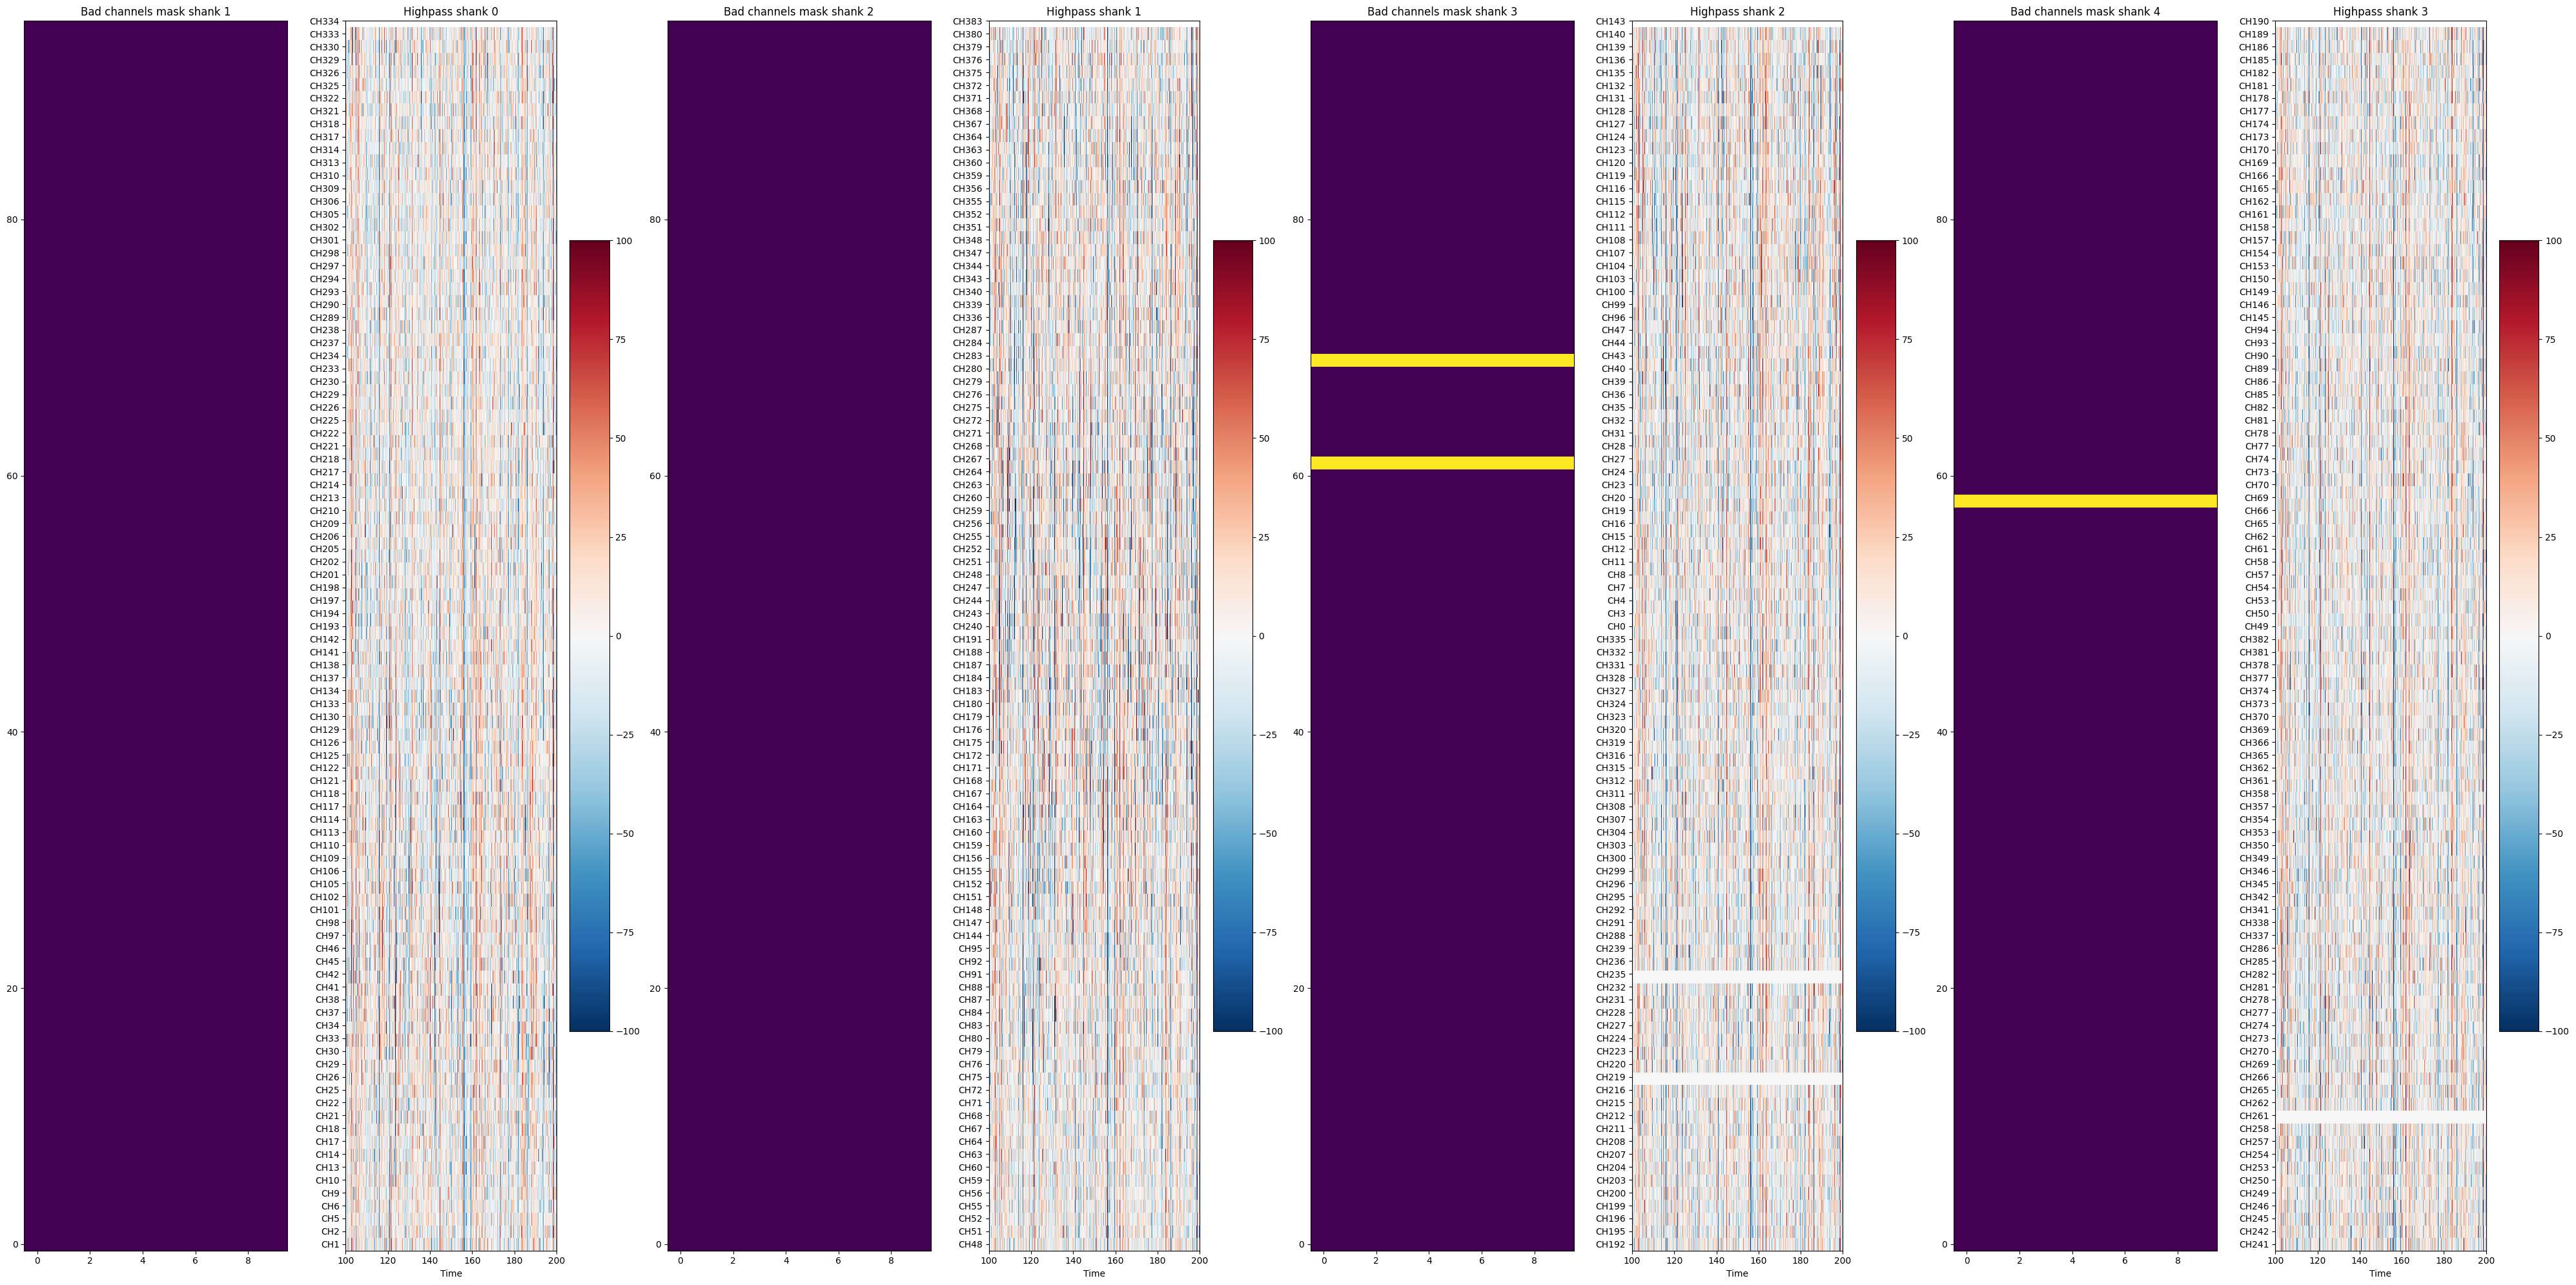

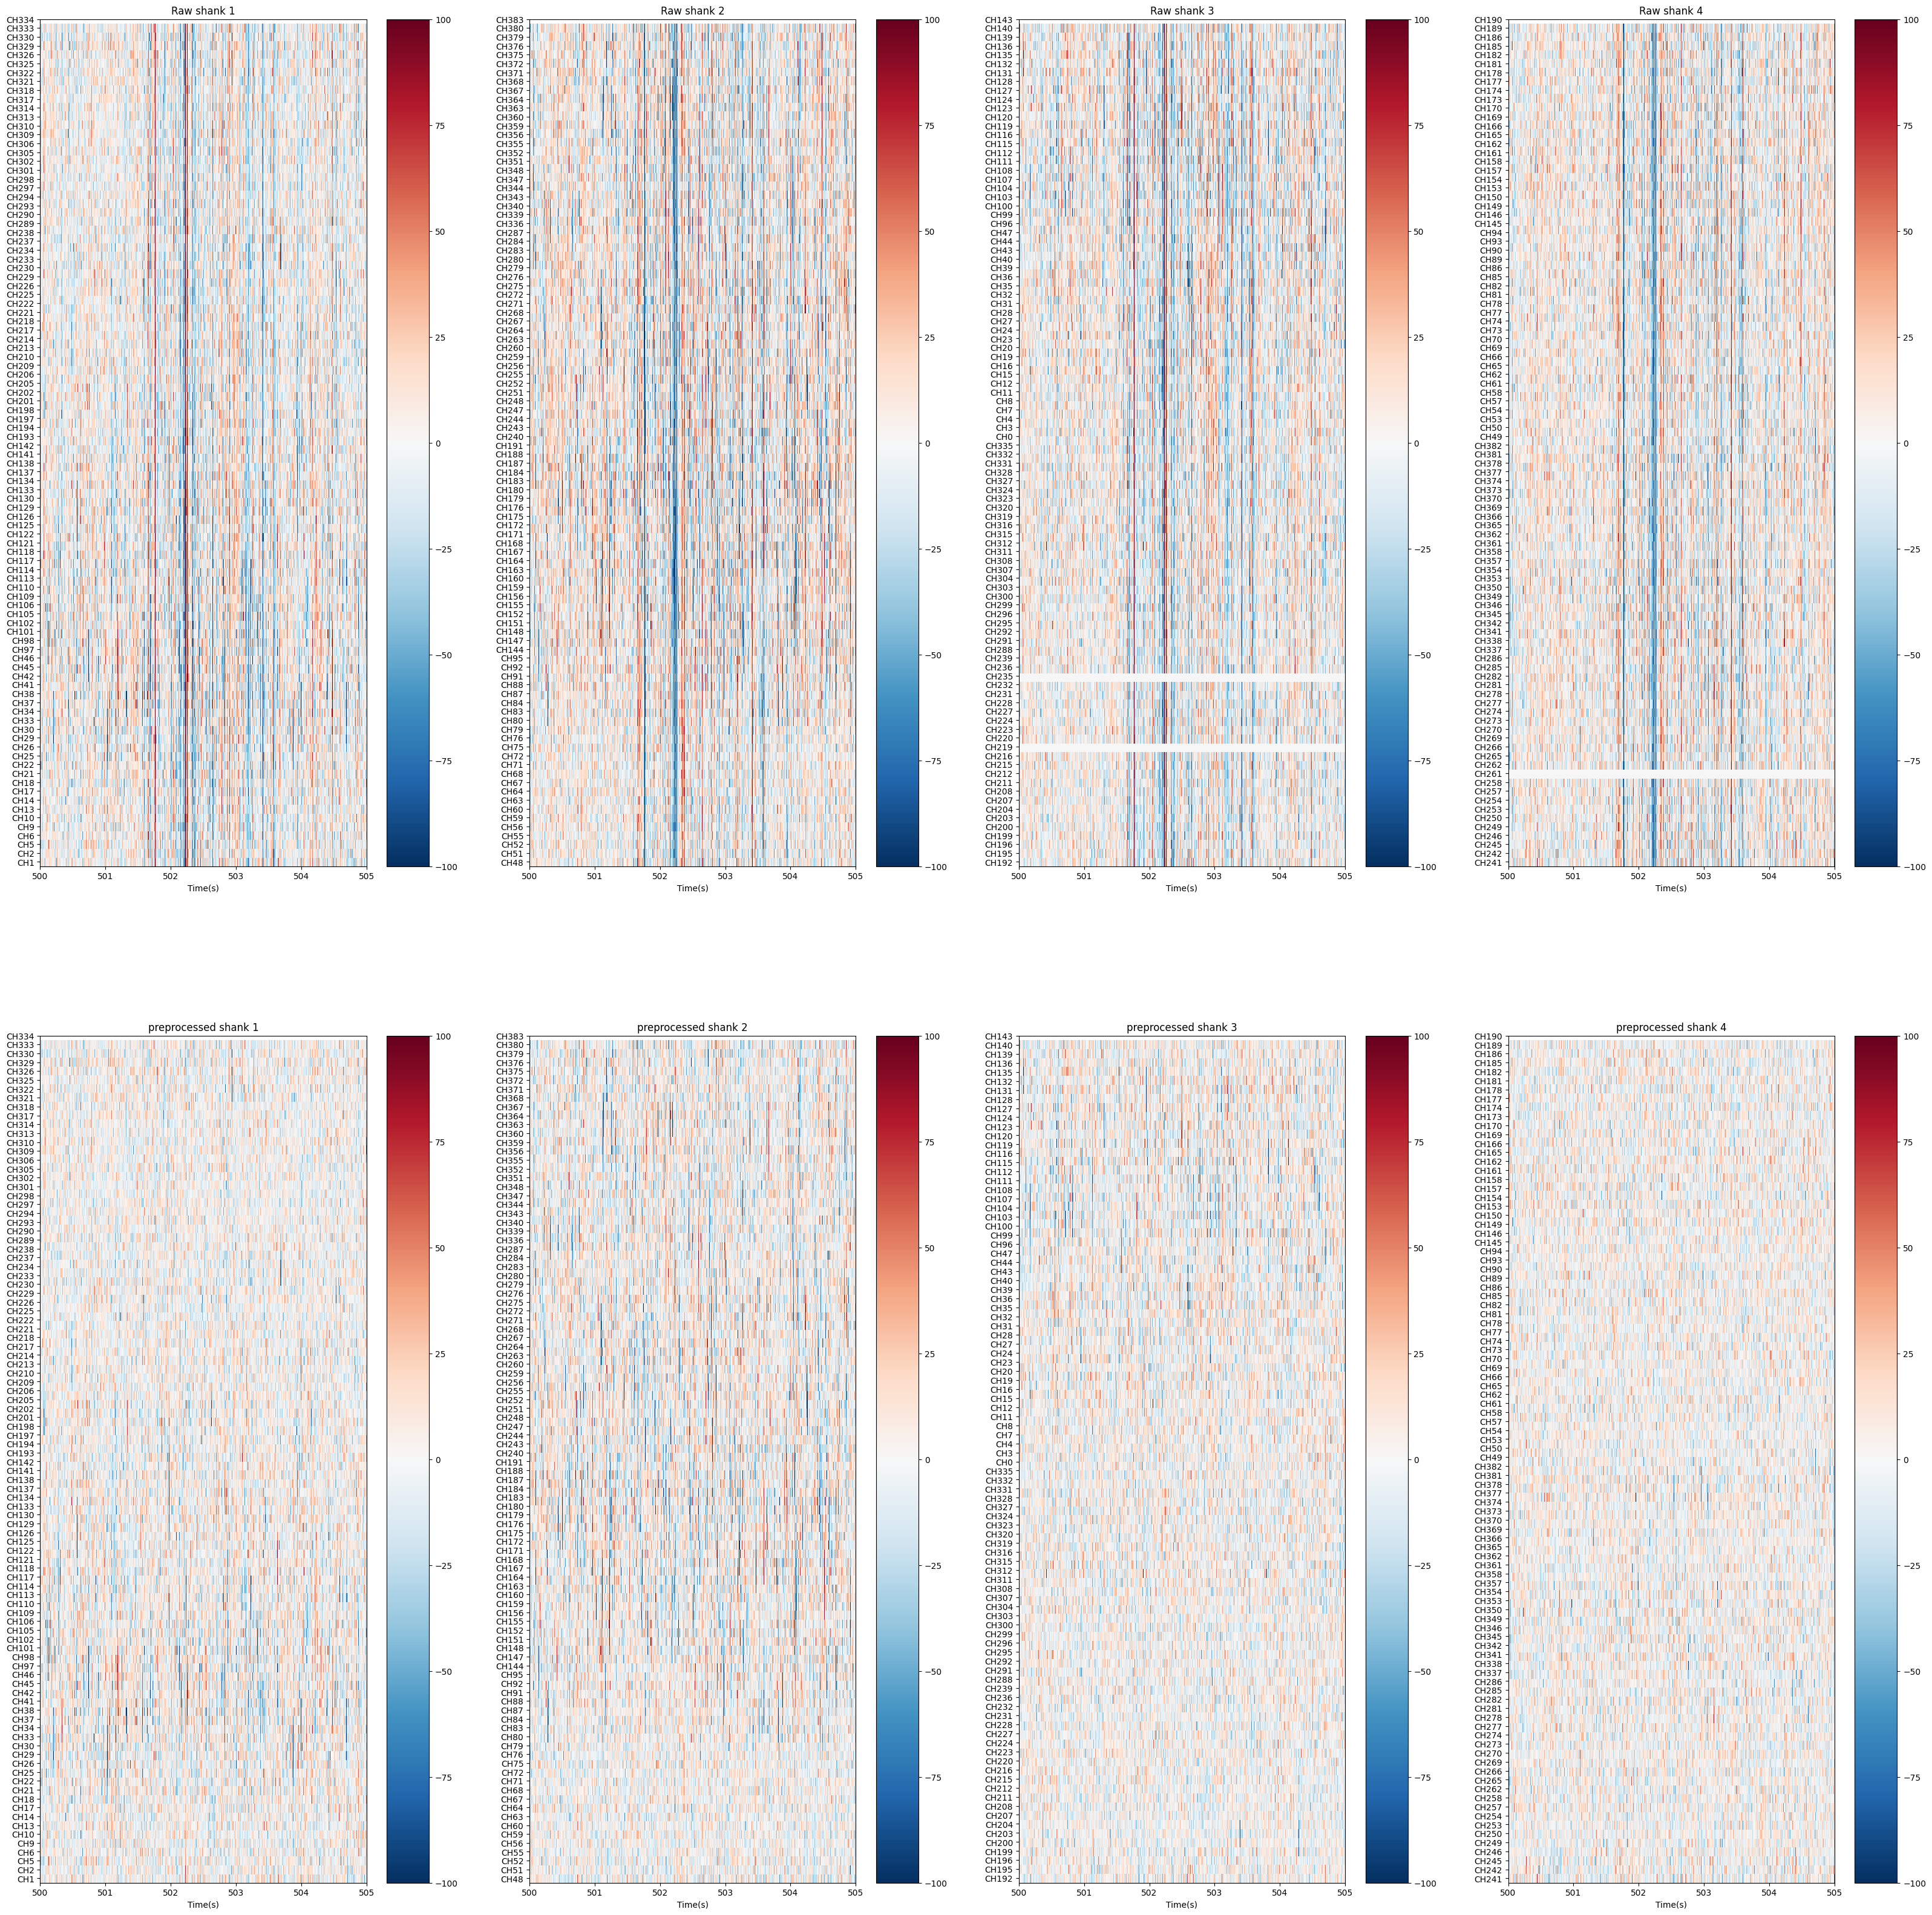

In [13]:
preprocessed_path = f"/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/{mouse}/{dates_string}_preprocessed"
preprocessed_merged = preprocess_merged(merged_, preprocessed_path=preprocessed_path, config_params_path=config_params_path)

In [14]:
job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True)

preprocessed_merged = preprocessed_merged.save(folder=f"/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/{mouse}/{dates_string}_preprocessed/binary", format='binary', **job_kwargs)

write_binary_recording 
n_jobs=40 - samples_per_chunk=30,000 - chunk_memory=21.80 MiB - total_memory=872.04 MiB - chunk_duration=1.00s


write_binary_recording:   0%|          | 0/8892 [00:00<?, ?it/s]

Text(0.5, 0, 'noise  [microV]')

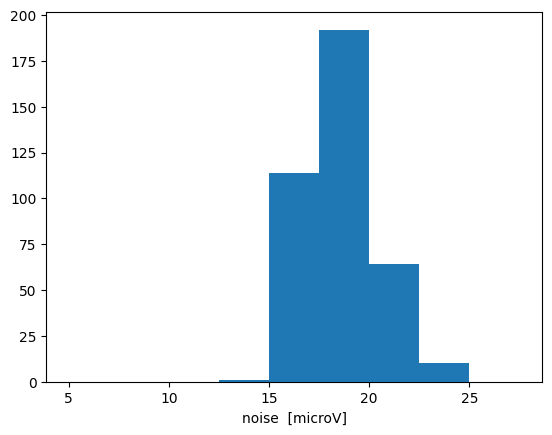

In [15]:
# we can estimate the noise on the scaled traces (microV) or on the raw one (which is in our case int16).
noise_levels_microV = si.get_noise_levels(preprocessed_merged, return_scaled=True)
noise_levels_int16 = si.get_noise_levels(preprocessed_merged, return_scaled=False)
fig, ax = plt.subplots()
_ = ax.hist(noise_levels_microV, bins=np.arange(5, 30, 2.5))
ax.set_xlabel('noise  [microV]')


In [16]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True)
peaks = detect_peaks(preprocessed_merged,  method='locally_exclusive', noise_levels=noise_levels_int16,
                     detect_threshold=5, radius_um=50., **job_kwargs)
peaks

detect peaks using locally_exclusive:   0%|          | 0/8892 [00:00<?, ?it/s]

array([(        6,  25, -539., 0), (       10, 157, -507., 0),
       (       12, 222, -593., 0), ..., (266755533, 139, -679., 0),
       (266755534, 329, -675., 0), (266755553, 247, -435., 0)],
      dtype=[('sample_index', '<i8'), ('channel_index', '<i8'), ('amplitude', '<f8'), ('segment_index', '<i8')])

In [17]:
from spikeinterface.sortingcomponents.peak_localization import localize_peaks

peak_locations = localize_peaks(preprocessed_merged, peaks, method='center_of_mass', radius_um=50., **job_kwargs)

localize peaks using center_of_mass:   0%|          | 0/8892 [00:00<?, ?it/s]

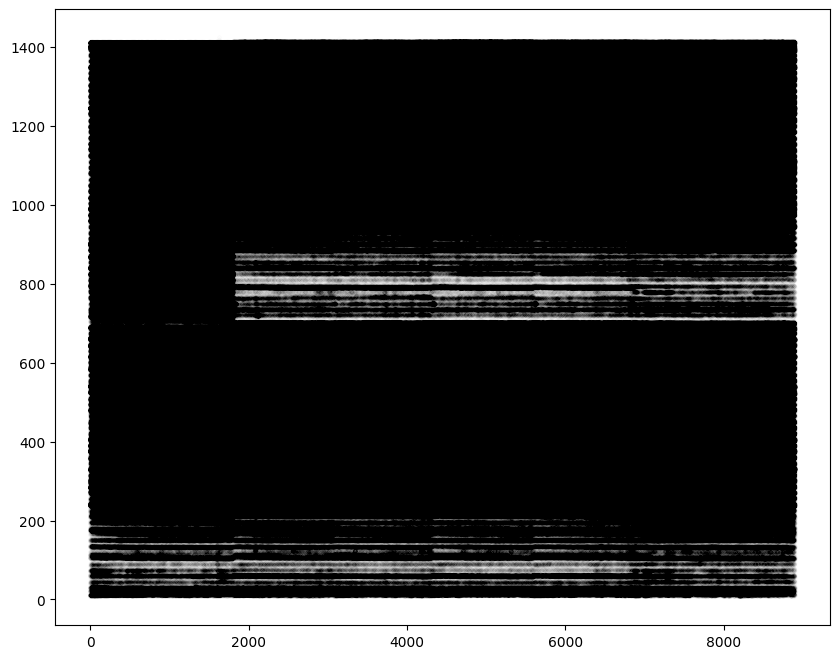

In [18]:

# check for drifts
fs = preprocessed_merged.sampling_frequency
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(peaks['sample_index'] / fs, peak_locations['y'], color='k', marker='.',  alpha=0.002)

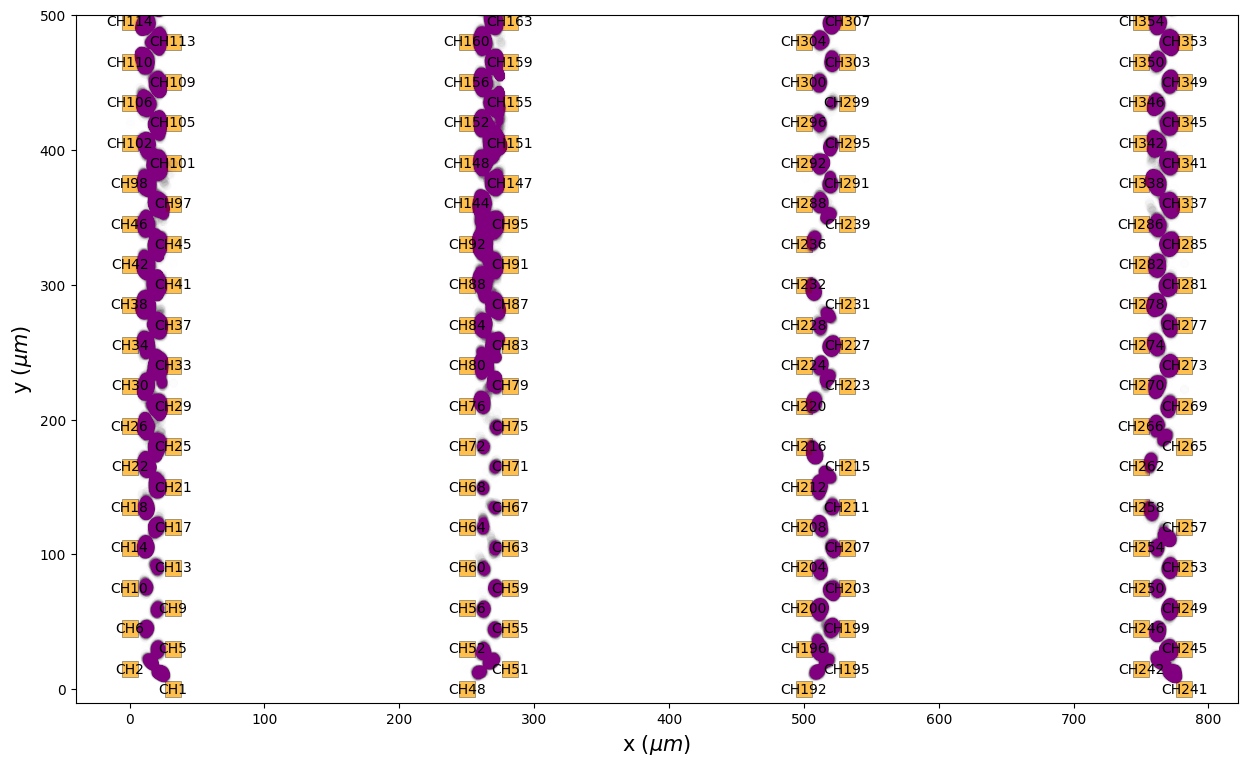

In [ ]:
import spikeinterface.full as sif

fig, ax = plt.subplots(figsize=(15, 10))
sif.plot_probe_map(preprocessed_merged, ax=ax, with_channel_ids=True)
ax.set_ylim(-10, 500)

ax.scatter(peak_locations['x'], peak_locations['y'], color='purple', alpha=0.002)

In [20]:
kilosort_output_path = f"{preprocessed_path}/kilosort_output/"
os.makedirs(kilosort_output_path, exist_ok=True)

kilosort_Ths = [9,8]
n_shanks = len(np.unique(preprocessed_merged.get_property("group")))

# Set up parameters for kilosort
sorter_params = ss.get_default_sorter_params("kilosort4")
# For optional changes to kilosort parameters
sorter_params["Th_universal"] = kilosort_Ths[0]
sorter_params["Th_learned"] = kilosort_Ths[1]
sorter_params["do_CAR"] = False  # we perform IBL destriping instead using spikeinterface


sorter = ss.run_sorter(
            "kilosort4",
            recording=preprocessed_merged,
            folder=kilosort_output_path,
            verbose=True,
            remove_existing_folder=True,
            **sorter_params,
        )
sorter = sc.remove_excess_spikes(sorter, preprocessed_merged)
sorter = sorter.remove_empty_units()

INFO:kilosort.run_kilosort: 
INFO:kilosort.run_kilosort:Computing preprocessing variables.
INFO:kilosort.run_kilosort:----------------------------------------


Skipping common average reference.


INFO:kilosort.run_kilosort:N samples: 266755561
INFO:kilosort.run_kilosort:N seconds: 8891.852033333333
INFO:kilosort.run_kilosort:N batches: 4446
INFO:kilosort.run_kilosort:Preprocessing filters computed in  131.23s; total  131.25s
INFO:kilosort.run_kilosort: 
INFO:kilosort.run_kilosort:Resource usage after preprocessing
INFO:kilosort.run_kilosort:********************************************************
INFO:kilosort.run_kilosort:CPU usage:     6.30 %
INFO:kilosort.run_kilosort:Memory:       13.97 %     |     70.34   /   503.51 GB
INFO:kilosort.run_kilosort:------------------------------------------------------
INFO:kilosort.run_kilosort:GPU usage:    `conda install pynvml` for GPU usage
INFO:kilosort.run_kilosort:GPU memory:    5.43 %     |      2.14   /    39.50 GB
INFO:kilosort.run_kilosort:Allocated:     0.02 %     |      0.01   /    39.50 GB
INFO:kilosort.run_kilosort:Max alloc:     3.28 %     |      1.30   /    39.50 GB
INFO:kilosort.run_kilosort:********************************

kilosort4 run time 17309.51s


In [39]:
def get_quality_metrics(sorter, preprocessed_rec, preprocessed_path, save_cluster_reports):
    sorter = sc.remove_excess_spikes(sorter, preprocessed_rec)
    analyzer_output_path = Path(f"{preprocessed_path}/sorting_analyzer")
    if analyzer_output_path.exists():
        print("Loading Analyzer from Disk")
        analyzer = si.load_sorting_analyzer(analyzer_output_path)
    else:
        print("Creating Analyzer")
        analyzer = si.create_sorting_analyzer(
            sorter,
            preprocessed_rec,
            sparse=True,
            format="binary_folder",
            folder=analyzer_output_path,
            overwrite=True,
            n_jobs=40, 
            chunk_duration="1s",
            progress_bar=True,
        )
        analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
        analyzer.compute("waveforms", ms_before=1.5, ms_after=2.0)
        print("calculating templates")
        analyzer.compute("templates", operators=["average", "median", "std"])
        print("calculating noise levels")
        analyzer.compute("noise_levels")
        print("calculating correlograms")
        analyzer.compute("correlograms")
        print("calculating unit locations")
        analyzer.compute("unit_locations")
        print("calculating spike amplitudes")
        analyzer.compute("spike_amplitudes")
        print("calculating spike locations")
        analyzer.compute("spike_locations")
        print("calculating template similarity")
        analyzer.compute("template_similarity")

    print("computing quality metrics df")
    metrics_list = sq.get_quality_metric_list()
    metrics_df = sq.compute_quality_metrics(analyzer, metric_names=metrics_list)
    # process metrics df
    metrics_df.reset_index(inplace=True)
    metrics_df.rename(columns={"index": "unit_id"}, inplace=True)
    metrics_df["amplitude_median"] = metrics_df["amplitude_median"].abs()
    # save cluster reports
    if save_cluster_reports:
        print("exporting cluster reports")
        try:
            sx.export_report(
                analyzer,
                output_folder=Path(f"{preprocessed_path}/cluster_reports"),
                remove_if_exists=True,
            )
        except ValueError:
            print("Failed generating cluster report")

    # si.plot_sorting_summary(analyzer, backend='sortingview')

    return metrics_df


def get_single_units(
    quality_metric_df,
    isi_violations_ratio_thres=0.1,
    amplitude_cutoff_thres=0.1,
    firing_rate_thres=0.1,
    presence_ratio_thres=0.9,
    amplitude_median_thres=20,  # For Neuropixel 2.0 - per shank CAR requires lowering this threshold.
    sd_ratio_thres=3,
):
    """
    Filter sortered clusters by quality metrics to find single units (clusters that pass QC metrics)

    Metrics:
    """
    isi_violations_mask = np.logical_or.reduce(
        [
            quality_metric_df.isi_violations_ratio < isi_violations_ratio_thres,
        ]
    )
    qc_pass_df = quality_metric_df[isi_violations_mask]
    remaining_query = f"amplitude_cutoff < {amplitude_cutoff_thres} and firing_rate > {firing_rate_thres} and presence_ratio > {presence_ratio_thres} and amplitude_median > {amplitude_median_thres} and sd_ratio < {sd_ratio_thres}"
    qc_pass_df = qc_pass_df.query(remaining_query)
    return qc_pass_df.unit_id.values

In [40]:
sorter

UnitsSelectionSorting: 1001 units - 1 segments - 30.0kHz

In [ ]:
quality_metrics_df = get_quality_metrics(sorter, preprocessed_merged, kilosort_output_path, save_cluster_reports=True)
quality_metrics_df.to_csv(f"{kilosort_output_path}/quality_metrics.htsv", sep="\t", index=False)
single_units = get_single_units(quality_metrics_df)
print(f"Found {len(single_units)} single units, passing quality control")

Creating Analyzer


estimate_sparsity:   0%|          | 0/8892 [00:00<?, ?it/s]

In [2]:
import numpy as np
import pandas as pd
import os

def get_single_units(
    quality_metric_df,
    isi_violations_ratio_thres=0.1,
    amplitude_cutoff_thres=0.1,
    firing_rate_thres=0.1,
    presence_ratio_thres=0.9,
    amplitude_median_thres=20,  # For Neuropixel 2.0 - per shank CAR requires lowering this threshold.
    sd_ratio_thres=3,
):
    """
    Filter sortered clusters by quality metrics to find single units (clusters that pass QC metrics)

    Metrics:
    """
    isi_violations_mask = np.logical_or.reduce(
        [
            quality_metric_df.isi_violations_ratio < isi_violations_ratio_thres,
        ]
    )
    qc_pass_df = quality_metric_df[isi_violations_mask]
    remaining_query = f"amplitude_cutoff < {amplitude_cutoff_thres} and firing_rate > {firing_rate_thres} and presence_ratio > {presence_ratio_thres} and amplitude_median > {amplitude_median_thres} and sd_ratio < {sd_ratio_thres}"
    qc_pass_df = qc_pass_df.query(remaining_query)
    return qc_pass_df.unit_id.values



base_path = "/ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys"

for mouse_dir in os.listdir(base_path):
    mouse_path = os.path.join(base_path, mouse_dir)
    if not os.path.isdir(mouse_path):
        continue

    for recording_dir in os.listdir(mouse_path):
        recording_path = os.path.join(mouse_path, recording_dir)
        if not os.path.isdir(recording_path):
            continue

        kilosort_path = os.path.join(recording_path, "kilosort_output")
        qc_file_path = os.path.join(kilosort_path, "QC_single_units.npy")

        if os.path.exists(qc_file_path):
            try:
                units = np.load(qc_file_path, allow_pickle=True)
                print(f"Found {len(units)} units in {qc_file_path}")
            except Exception as e:
                print(f"Error loading {qc_file_path}: {e}")


Found 76 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly06/2025-06-18_2025-06-19_preprocessed/kilosort_output/QC_single_units.npy
Found 66 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly06/2025-06-24_2025-06-25_preprocessed/kilosort_output/QC_single_units.npy
Found 68 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly06/2025-06-13_2025-06-15_preprocessed/kilosort_output/QC_single_units.npy
Found 67 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly06/2025-06-20_2025-06-23_preprocessed/kilosort_output/QC_single_units.npy
Found 79 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly06/2025-06-16_2025-06-17_preprocessed/kilosort_output/QC_single_units.npy
Found 88 units in /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/preprocessed/ephys/ly07/2025-06-18_2025-06-19_preprocessed/kilosort_output/

In [ ]:
from spikeinterface.exporters import export_to_phy

phy_output_path = preprocessed_path / "phy"
os.makedirs(phy_output_path, exist_ok=True)

# the waveforms are sparse so it is faster to export to phy
sorting_analyzer = si.create_sorting_analyzer(sorting=sorter, recording=preprocessed_merged)

# some computations are done before to control all options
sorting_analyzer.compute(['random_spikes', 'waveforms', 'templates', 'noise_levels'])
_ = sorting_analyzer.compute('spike_amplitudes')
_ = sorting_analyzer.compute('principal_components', n_components = 5, mode="by_channel_local")

# the export process is fast because everything is pre-computed
export_to_phy(sorting_analyzer=sorting_analyzer, output_folder=phy_output_path)

In [ ]:




# save single units to file
print("Exporting to phy format")
export_to_phy(preprocessed_merged, sorter, output_folder=phy_output_path)
